<a href="https://colab.research.google.com/github/jaredmerlo-and-we-back/computer-vision/blob/main/Homework2_CompVis_--TransferLearning%20on%20Yoga%20Pose%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASSIGNMENT 2 -- Transfer Learning


In [13]:
!pip install pydot

In [14]:
pip install tensorflow

In [15]:
pip install tensorboard

In [16]:
from tensorflow.keras import Input, Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,concatenate
from tensorflow.keras.utils import plot_model

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

**HOMEWORK PROBLEM #4 **




In [18]:
## STEP 0 -- retrieve and unpack the dataset

import kagglehub
import os
from google.colab import drive

# Mount drive (if needed for other files, but not for this dataset download)
drive.mount('/content/drive')

# Ensure local data directory structure exists
local_base_parent = '/content/local_data/computer-vision/yogaposes'
os.makedirs(local_base_parent, exist_ok=True) # Use exist_ok=True for robustness

# Download the dataset zip file using Kaggle CLI
# This downloads to /content/yoga-poses-dataset-107.zip
print("Downloading dataset from Kaggle...")
!kaggle datasets download -d arrowe/yoga-poses-dataset-107

# Unzip the downloaded dataset into the local_base_parent directory
# This will create '107 yoga poses' inside 'yogaposes'
print(f"Unzipping dataset to {local_base_parent}...")
!unzip -o "/content/yoga-poses-dataset-107.zip" -d {local_base_parent}

# Verify content
print("\nContents of the target directory after unzipping:")
!ls -la {local_base_parent}

# Remove the zip file to save space
!rm "/content/yoga-poses-dataset-107.zip"

Streaming output truncated to the last 5000 lines.
  inflating: /content/local_data/computer-vision/yogaposes/107 yoga poses/train/ardha matsyendrasana/49-0.png  
  inflating: /content/local_data/computer-vision/yogaposes/107 yoga poses/train/ardha matsyendrasana/50-0.png  
  inflating: /content/local_data/computer-vision/yogaposes/107 yoga poses/train/ardha matsyendrasana/51-0.png  
  inflating: /content/local_data/computer-vision/yogaposes/107 yoga poses/train/ardha matsyendrasana/52-0.png  
  inflating: /content/local_data/computer-vision/yogaposes/107 yoga poses/train/ardha matsyendrasana/53-0.png  
  inflating: /content/local_data/computer-vision/yogaposes/107 yoga poses/train/ardha matsyendrasana/53-1.png  
  inflating: /content/local_data/computer-vision/yogaposes/107 yoga poses/train/ardha matsyendrasana/53-2.png  
  inflating: /content/local_data/computer-vision/yogaposes/107 yoga poses/train/ardha matsyendrasana/54-0.png  
  inflating: /content/local_data/computer-vision/yoga

In [19]:
SUBSET_CLASSES = [
    'adho mukha svanasana',
    'balasana',
    'bhujangasana',
    'tadasana',
    'trikonasana',
    'virabhadrasana i',
    'virabhadrasana ii',
    'vriksasana',
    'ustrasana',
    'savasana'
]
print(f"Training/evaluating with {len(SUBSET_CLASSES)} classes: {SUBSET_CLASSES}")

Training/evaluating with 10 classes: ['adho mukha svanasana', 'balasana', 'bhujangasana', 'tadasana', 'trikonasana', 'virabhadrasana i', 'virabhadrasana ii', 'vriksasana', 'ustrasana', 'savasana']


In [20]:
#!curl https://www.kaggle.com/api/v1/datasets/download/arrowe/yoga-poses-dataset-107 -o "yoga-poses-dataset-107.zip"
!ls -la 'local_data/computer-vision/yogaposes/107 yoga poses/test/adho mukha svanasana' #/computer-vision/yogaposes/ #/computer_vision/ #drive/MyDrive #drive/MyDrive/ #local_data #/computer-vision

total 2320
drwxr-xr-x   2 root root   4096 May 24 22:00  .
drwxr-xr-x 109 root root   4096 May 24 21:51  ..
-rw-r--r--   1 root root 172235 Feb 23  2023 '11. yoga_anatomy_using_muscle_awareness_to_lower_your_heels_in_downward_facing_dog_pose.png'
-rw-r--r--   1 root root 465140 Feb 23  2023 '13. downward-facing-dog-800x490.png'
-rw-r--r--   1 root root 172129 Feb 23  2023 '21. adho-mukha-svanasana.png'
-rw-r--r--   1 root root 767993 Feb 23  2023 '24. dsc_1007-resized-600.jpg'
-rw-r--r--   1 root root 228200 Feb 23  2023 '39. screen-shot-2019-01-02-at-5.02.56-pm.png'
-rw-r--r--   1 root root 376116 Feb 23  2023 '45. 3_alignment_instructions_to_reconsider.png'
-rw-r--r--   1 root root  34468 Feb 23  2023 '4. downward-facing-dog.png'
-rw-r--r--   1 root root 134206 Feb 23  2023 '60. adho-mukha-svanasana-downward-dog.png'


In [21]:
!unzip -o "yoga-poses-dataset-107.zip" -d local_data/computer-vision/yogaposes/

unzip:  cannot find or open yoga-poses-dataset-107.zip, yoga-poses-dataset-107.zip.zip or yoga-poses-dataset-107.zip.ZIP.


In [22]:
!ls -la 'local_data/computer-vision/yogaposes/107 yoga poses/test/adho mukha svanasana' #/computer-vision/yogaposes/ #/computer_vision/ #drive/MyDrive #drive/MyDrive/ #local_data #/computer-vision

total 2320
drwxr-xr-x   2 root root   4096 May 24 22:00  .
drwxr-xr-x 109 root root   4096 May 24 21:51  ..
-rw-r--r--   1 root root 172235 Feb 23  2023 '11. yoga_anatomy_using_muscle_awareness_to_lower_your_heels_in_downward_facing_dog_pose.png'
-rw-r--r--   1 root root 465140 Feb 23  2023 '13. downward-facing-dog-800x490.png'
-rw-r--r--   1 root root 172129 Feb 23  2023 '21. adho-mukha-svanasana.png'
-rw-r--r--   1 root root 767993 Feb 23  2023 '24. dsc_1007-resized-600.jpg'
-rw-r--r--   1 root root 228200 Feb 23  2023 '39. screen-shot-2019-01-02-at-5.02.56-pm.png'
-rw-r--r--   1 root root 376116 Feb 23  2023 '45. 3_alignment_instructions_to_reconsider.png'
-rw-r--r--   1 root root  34468 Feb 23  2023 '4. downward-facing-dog.png'
-rw-r--r--   1 root root 134206 Feb 23  2023 '60. adho-mukha-svanasana-downward-dog.png'


Dataset already copied.
Dataset copied successfully.
Found 4147 images belonging to 107 classes.
Found 1157 images belonging to 107 classes.
Found 687 images belonging to 107 classes.
Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - accuracy: 0.0123 - loss: 4.6719 - val_accuracy: 0.0156 - val_loss: 4.6583 - learning_rate: 0.0100
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.0128 - loss: 4.6582 - val_accuracy: 0.0156 - val_loss: 4.6416 - learning_rate: 0.0100
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.0231 - loss: 4.6140 - val_accuracy: 0.0761 - val_loss: 4.5316 - learning_rate: 0.0100
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.0723 - loss: 4.3455 - val_accuracy: 0.1547 - val_loss: 3.9940 - learning_rate: 0.0100
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.1719 - loss: 3.7225 - val_accuracy: 0.2679 - val_loss: 3.3874 - learning_rate: 0.0100
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1

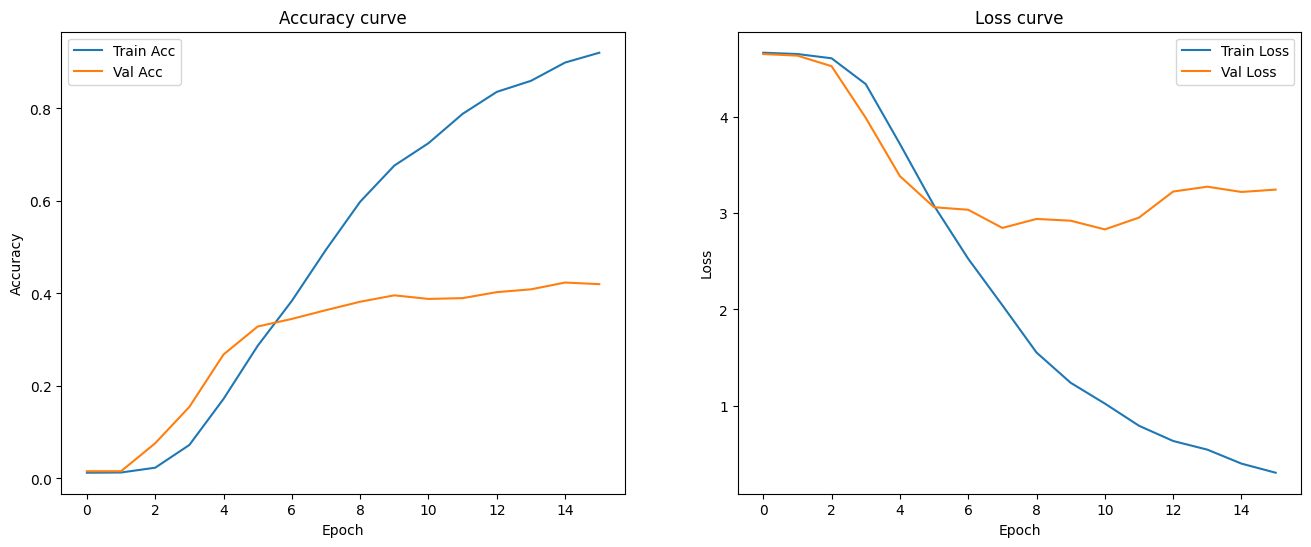

In [23]:
# # STEP 1 -- Run the Basic CNN to establish some baseline for comparing transfer model against --

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import shutil
import time

# --- Copy dataset from Google Drive to Colab local storage ---
drive_base = '/content/drive/MyDrive/computer-vision/yogaposes/107 yoga poses'
local_base = "/content/local_data/computer-vision/yogaposes/107 yoga poses"

if not os.path.exists(local_base):
    print("Copying dataset from Google Drive to Colab local storage...")
    shutil.copytree(drive_base, local_base)
else:
    print("Dataset already copied.")
print("Dataset copied successfully.")

# Directories
train_dir = os.path.join(local_base, 'train')
val_dir   = os.path.join(local_base, 'val')
test_dir  = os.path.join(local_base, 'test')

img_height, img_width = 128, 128
batch_size = 32

# Data Generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical', shuffle=True)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical', shuffle=True)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical', shuffle=False)

num_classes = len(train_generator.class_indices)  # automatically detected from directory

# Model Definition
def build_model():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model()

# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)
tensorboard_cb = callbacks.TensorBoard(log_dir='./logs', histogram_freq=1)

# Compile
base_lr = 0.01
model.compile(
    optimizer=optimizers.SGD(learning_rate=base_lr, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train with timing
start_time = time.time()
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, lr_schedule, tensorboard_cb]
)
print(f"Training time: {(time.time()-start_time)/60:.2f} minutes")

# Evaluate
test_generator.reset()
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# Trim predictions to match the actual number of test samples
y_pred = y_pred[:len(y_true)]

acc = np.mean(y_pred == y_true)
f1 = f1_score(y_true, y_pred, average='weighted')
cm = confusion_matrix(y_true, y_pred)
print(f'Accuracy: {acc:.4f}')
print(f'F1 Score: {f1:.4f}')
print('Classification Report:')

# Guard against missing classes in test set
present_labels = sorted(set(y_true))
present_class_names = [list(test_generator.class_indices.keys())[i] for i in present_labels]
print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_class_names))

# Visualizations
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curve')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curve')
plt.show()

In [24]:
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))


                               precision    recall  f1-score   support

         adho mukha svanasana       0.25      0.38      0.30         8
        adho mukha vriksasana       0.29      0.29      0.29         7
              agnistambhasana       0.50      0.25      0.33         4
              ananda balasana       0.60      0.43      0.50         7
                   anantasana       0.36      0.80      0.50         5
                 anjaneyasana       0.22      0.50      0.31         8
              ardha bhekasana       0.08      0.25      0.12         4
            ardha chandrasana       0.60      0.50      0.55         6
         ardha matsyendrasana       0.21      0.40      0.28        10
      ardha pincha mayurasana       0.33      0.33      0.33         6
             ardha uttanasana       0.38      0.43      0.40         7
           ashtanga namaskara       0.75      0.60      0.67         5
                astavakrasana       0.75      0.75      0.75         8
     

In [25]:
print(len(y_true))
print(len(y_pred))
print(y_true)
print(y_pred)

687
687
[  0   0   0   0   0   0   0   0   1   1   1   1   1   1   1   2   2   2   2   3   3   3   3   3   3   3   4   4   4   4   4   5   5   5   5   5   5   5   5   6   6   6   6   7   7   7   7   7   7   8   8   8   8   8   8   8   8   8   8   9   9   9   9   9   9  10  10  10  10  10  10  10  11  11  11  11  11  12  12
  12  12  12  12  12  12  13  13  13  13  13  13  13  14  14  14  14  14  14  14  14  14  15  15  15  15  15  15  15  15  16  16  16  16  16  17  17  17  17  17  17  17  18  18  18  18  18  19  19  19  19  19  19  19  19  20  20  20  20  20  20  20  21  21  21  21  21  21  21  21  21  21  22  22  22  22  22  22  22
  23  23  23  23  23  23  23  24  24  24  24  24  24  24  24  24  24  25  25  25  25  25  25  26  26  26  26  26  27  27  27  27  27  28  28  28  28  28  28  29  29  29  29  29  29  30  30  30  30  30  30  30  31  31  31  31  31  31  32  32  32  32  32  32  33  33  33  33  33  34  34  34  34  35  35  35  35  35  35
  35  35  35  36  36  36  36  36  36  36 

In [26]:
list(test_generator.class_indices.keys())

['adho mukha svanasana',
 'adho mukha vriksasana',
 'agnistambhasana',
 'ananda balasana',
 'anantasana',
 'anjaneyasana',
 'ardha bhekasana',
 'ardha chandrasana',
 'ardha matsyendrasana',
 'ardha pincha mayurasana',
 'ardha uttanasana',
 'ashtanga namaskara',
 'astavakrasana',
 'baddha konasana',
 'bakasana',
 'balasana',
 'bhairavasana',
 'bharadvajasana i',
 'bhekasana',
 'bhujangasana',
 'bhujapidasana',
 'bitilasana',
 'camatkarasana',
 'chakravakasana',
 'chaturanga dandasana',
 'dandasana',
 'dhanurasana',
 'durvasasana',
 'dwi pada viparita dandasana',
 'eka pada koundinyanasana i',
 'eka pada koundinyanasana ii',
 'eka pada rajakapotasana',
 'eka pada rajakapotasana ii',
 'ganda bherundasana',
 'garbha pindasana',
 'garudasana',
 'gomukhasana',
 'halasana',
 'hanumanasana',
 'janu sirsasana',
 'kapotasana',
 'krounchasana',
 'kurmasana',
 'lolasana',
 'makara adho mukha svanasana',
 'makarasana',
 'malasana',
 'marichyasana i',
 'marichyasana iii',
 'marjaryasana',
 'matsyasa

Dataset already copied.
Dataset copied successfully.
Found 4147 images belonging to 107 classes.
Found 1157 images belonging to 107 classes.
Found 687 images belonging to 107 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Trainable layers: 6 / 6
Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 57s 392ms/step - accuracy: 0.0159 - loss: 4.6792 - val_accuracy: 0.0493 - val_loss: 4.5048 - learning_rate: 1.0000e-04
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 50s 382ms/step - accuracy: 0.0598 - loss: 4.4372 - val_accuracy: 0.1314 - val_loss: 4.1671 - learning_rate: 1.0000e-04
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 50s 381ms/step - accuracy: 0.1256 - loss: 4.1021 - val_accuracy: 0.2342 - val_loss: 3.5928 - learning_rate: 1.0000e-04
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 50s 381ms/step - accuracy: 0.1953 - loss: 3.6326 - val_accuracy: 0.3319 - val_loss: 3.0629 - learning_rate: 1.0000e-04
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 50s 381ms/step - accuracy: 0.2616 - loss: 3.2160 - val_accuracy: 

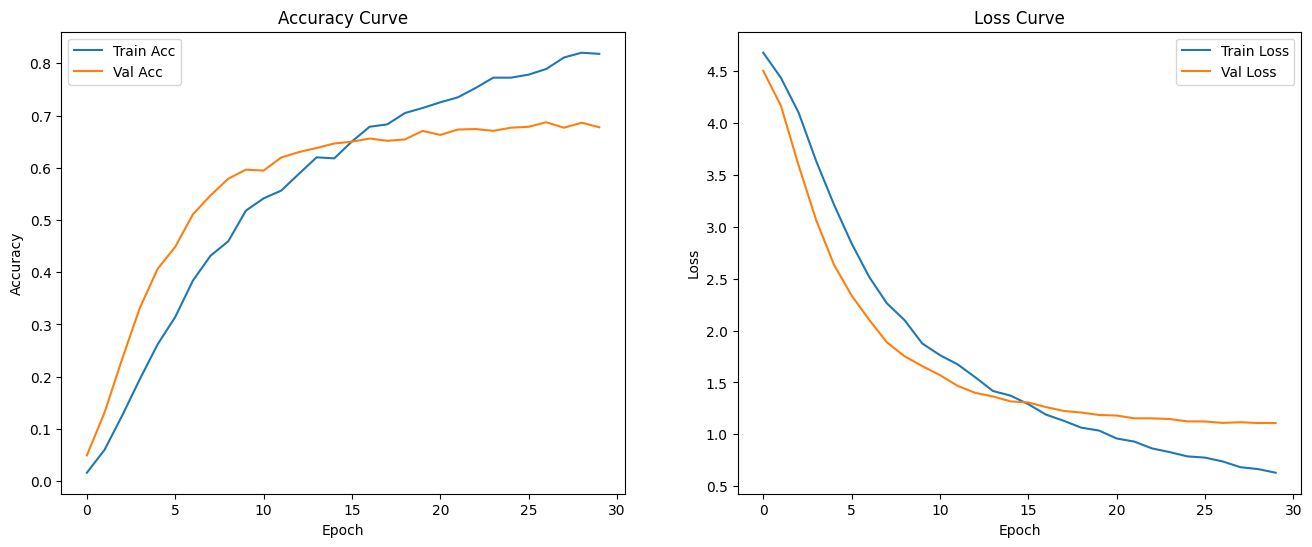

In [27]:
# Transfer learning model leveraging EfficientNet --
# Code Generated by Sidekick is for learning and experimentation purposes only.

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import shutil
import time

# --- Copy dataset from Google Drive to Colab local storage ---
drive_base = '/content/drive/MyDrive/computer-vision/yogaposes/107 yoga poses'
local_base = "/content/local_data/computer-vision/yogaposes/107 yoga poses"

if not os.path.exists(local_base):
    print("Copying dataset from Google Drive to Colab local storage...")
    shutil.copytree(drive_base, local_base)
else:
    print("Dataset already copied.")
print("Dataset copied successfully.")

# Directories
train_dir = os.path.join(local_base, 'train')
val_dir   = os.path.join(local_base, 'val')
test_dir  = os.path.join(local_base, 'test')

# --- UPDATED: 224x224 is the native resolution EfficientNet was pretrained on ---
img_height, img_width = 224, 224
batch_size = 32

# --- UPDATED: No rescaling — EfficientNetB0 has built-in preprocessing ---
# --- UPDATED: Augmentation added to training generator to improve generalization ---
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen  = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='categorical', shuffle=True)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='categorical', shuffle=True)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='categorical', shuffle=False)

num_classes = train_generator.num_classes

# --- UPDATED: EfficientNetB0 transfer learning with last 20 layers trainable ---
def build_model():
    # Load EfficientNetB0 pretrained on ImageNet, without the top classification head
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_height, img_width, 3)
    )

    # Freeze all layers, then selectively unfreeze the last 20
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    # Functional API to attach a custom classification head
    inputs = keras.Input(shape=(img_height, img_width, 3))

    # training=False keeps BatchNorm layers in inference mode during fine-tuning
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

model = build_model()

# Optional: confirm which layers are trainable
trainable_count = sum(1 for layer in model.layers if layer.trainable)
print(f"Trainable layers: {trainable_count} / {len(model.layers)}")

# Callbacks (unchanged)
early_stop    = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_schedule   = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)
tensorboard_cb = callbacks.TensorBoard(log_dir='./logs', histogram_freq=1)

# --- UPDATED: Adam at 1e-4 — fine-tuning pretrained weights requires small, careful updates ---
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train with timing (unchanged)
start_time = time.time()
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, lr_schedule, tensorboard_cb]
)
print(f"Training time: {(time.time()-start_time)/60:.2f} minutes")

# Evaluate (unchanged)
test_generator.reset()
preds  = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

acc = np.mean(y_pred == y_true)
f1  = f1_score(y_true, y_pred, average='weighted')
cm  = confusion_matrix(y_true, y_pred)

print(f'Accuracy: {acc:.4f}')
print(f'F1 Score: {f1:.4f}')
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

# Visualizations (unchanged)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')


plt.show()


In [28]:
"""
Transfer Learning Results Analysis

Head-to-Head Comparison

Metric	Basic CNN	EfficientNetB0	Improvement
Test Accuracy	39.2%	69.4%	+30.2 pp
Weighted F1	0.37	0.68	+0.31
Macro F1	0.36	0.67	+0.31
Training Time	3.97 min	24.57 min	6x longer
Epochs run	14	30	Didn't convergea
Key Observations

What improved dramatically:

Classes like anantasana, ardha bhekasana, bhairavasana, krounchasana, marichyasana iii, vriksasana, virabhadrasana ii all hit F1: 1.00 — the model learned these perfectly
The val accuracy was still climbing at epoch 30 (68.6% → still trending up), meaning early stopping never triggered and the model hadn't fully converged
Remaining problem classes (F1 = 0.00):

chakravakasana, padangusthasana, pincha mayurasana, tulasana — these likely have visual ambiguity with similar poses or very few/unrepresentative test samples
Overfitting is much reduced:

Train acc: 82% vs Val acc: 69% — gap is ~13pp compared to ~49pp in the basic CNN
"""


"\nTransfer Learning Results Analysis\n\nHead-to-Head Comparison\n\nMetric\tBasic CNN\tEfficientNetB0\tImprovement\nTest Accuracy\t39.2%\t69.4%\t+30.2 pp\nWeighted F1\t0.37\t0.68\t+0.31\nMacro F1\t0.36\t0.67\t+0.31\nTraining Time\t3.97 min\t24.57 min\t6x longer\nEpochs run\t14\t30\tDidn't convergea\nKey Observations\n\nWhat improved dramatically:\n\nClasses like anantasana, ardha bhekasana, bhairavasana, krounchasana, marichyasana iii, vriksasana, virabhadrasana ii all hit F1: 1.00 — the model learned these perfectly\nThe val accuracy was still climbing at epoch 30 (68.6% → still trending up), meaning early stopping never triggered and the model hadn't fully converged\nRemaining problem classes (F1 = 0.00):\n\nchakravakasana, padangusthasana, pincha mayurasana, tulasana — these likely have visual ambiguity with similar poses or very few/unrepresentative test samples\nOverfitting is much reduced:\n\nTrain acc: 82% vs Val acc: 69% — gap is ~13pp compared to ~49pp in the basic CNN\n"

Found 687 images belonging to 107 classes.
Classes: 107 | Samples: 687

Loading EfficientNetB0 feature extractor...
Extracting features...
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step
Feature extraction time: 0.09 minutes
Raw feature shape: (687, 1280)
Flattened & normalised feature shape: (687, 1280)

Applying PCA...
PCA: 100 components explain 74.7% of variance

Running Elbow Method...
  k=  5 | Inertia: 282 | Silhouette: 0.0501
  k= 10 | Inertia: 261 | Silhouette: 0.0416
  k= 15 | Inertia: 247 | Silhouette: 0.0459
  k= 20 | Inertia: 241 | Silhouette: 0.0406
  k= 25 | Inertia: 233 | Silhouette: 0.0368
  k= 30 | Inertia: 228 | Silhouette: 0.0413
  k= 35 | Inertia: 223 | Silhouette: 0.0384
  k= 40 | Inertia: 219 | Silhouette: 0.0368
  k= 45 | Inertia: 213 | Silhouette: 0.0349
  k= 50 | Inertia: 209 | Silhouette: 0.0320
  k= 55 | Inertia: 205 | Silhouette: 0.0334
  k= 60 | Inertia: 202 | Silhouette: 0.0304
  k= 65 | Inertia: 199 | Silhouette: 0.0377
  k= 70 | Inertia: 195 | Silhouette: 0.02

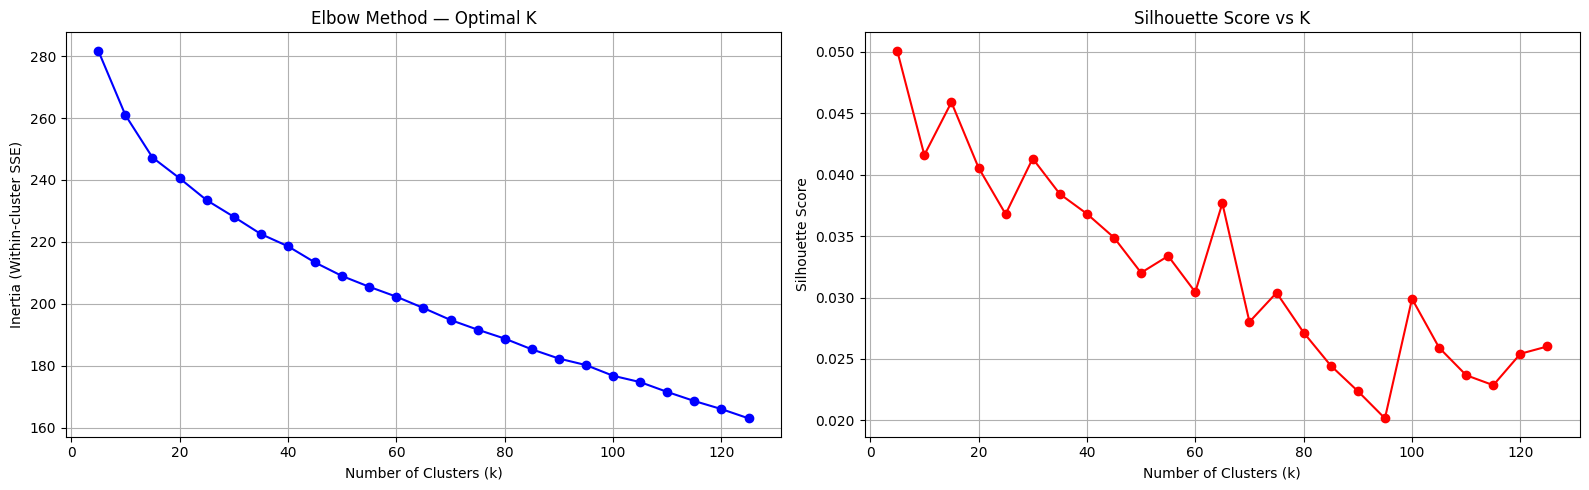


Best k by Silhouette Score: 5 (score: 0.0501)

Fitting final KMeans with k=5...
KMeans (k=5) Results:
  Silhouette Score  : 0.0514   (higher is better, max=1)
  Davies-Bouldin    : 3.5328    (lower is better)
  Adjusted Rand     : 0.0083   (1=perfect match with true labels)

Fitting DBSCAN...
DBSCAN found 1 clusters | Noise points: 0/687
DBSCAN did not find meaningful clusters — try adjusting eps and min_samples.

Generating PCA 2D visualisations...


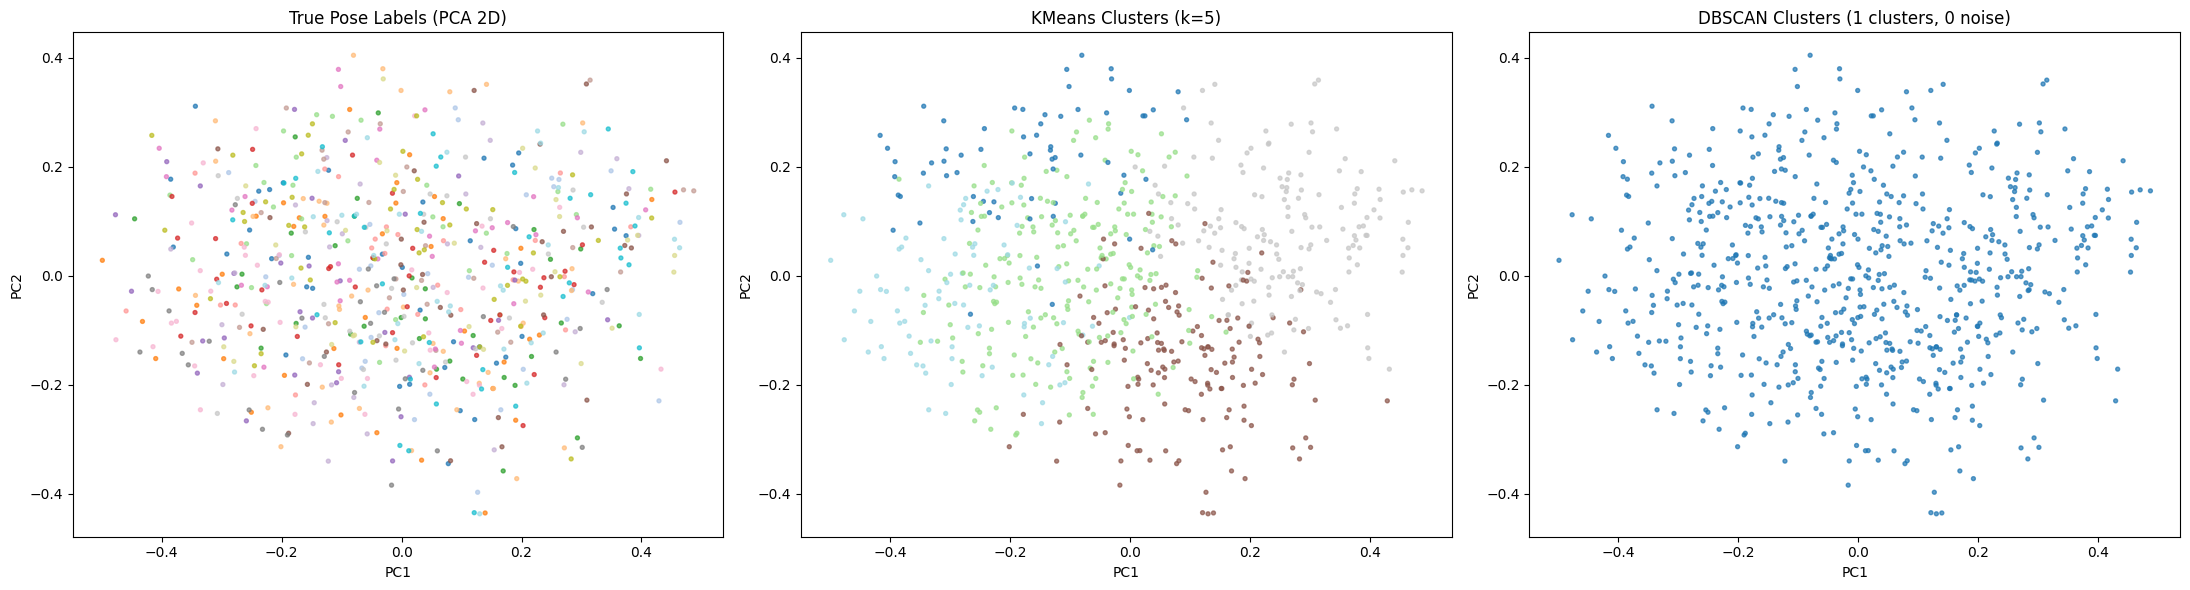


Analysing how KMeans clusters map to true pose classes...

Top poses per KMeans cluster (k=5):
  Cluster   0 ( 65 imgs): bhairavasana(3), urdhva prasarita eka padasana(3), camatkarasana(2)
  Cluster   1 (214 imgs): pasasana(6), ananda balasana(5), bakasana(5)
  Cluster   2 (157 imgs): bitilasana(7), baddha konasana(6), gomukhasana(6)
  Cluster   3 (166 imgs): virabhadrasana ii(6), parivrtta trikonasana(6), natarajasana(5)
  Cluster   4 ( 85 imgs): savasana(7), supta virasana(5), ashtanga namaskara(4)

Generating cluster-vs-class heatmap...


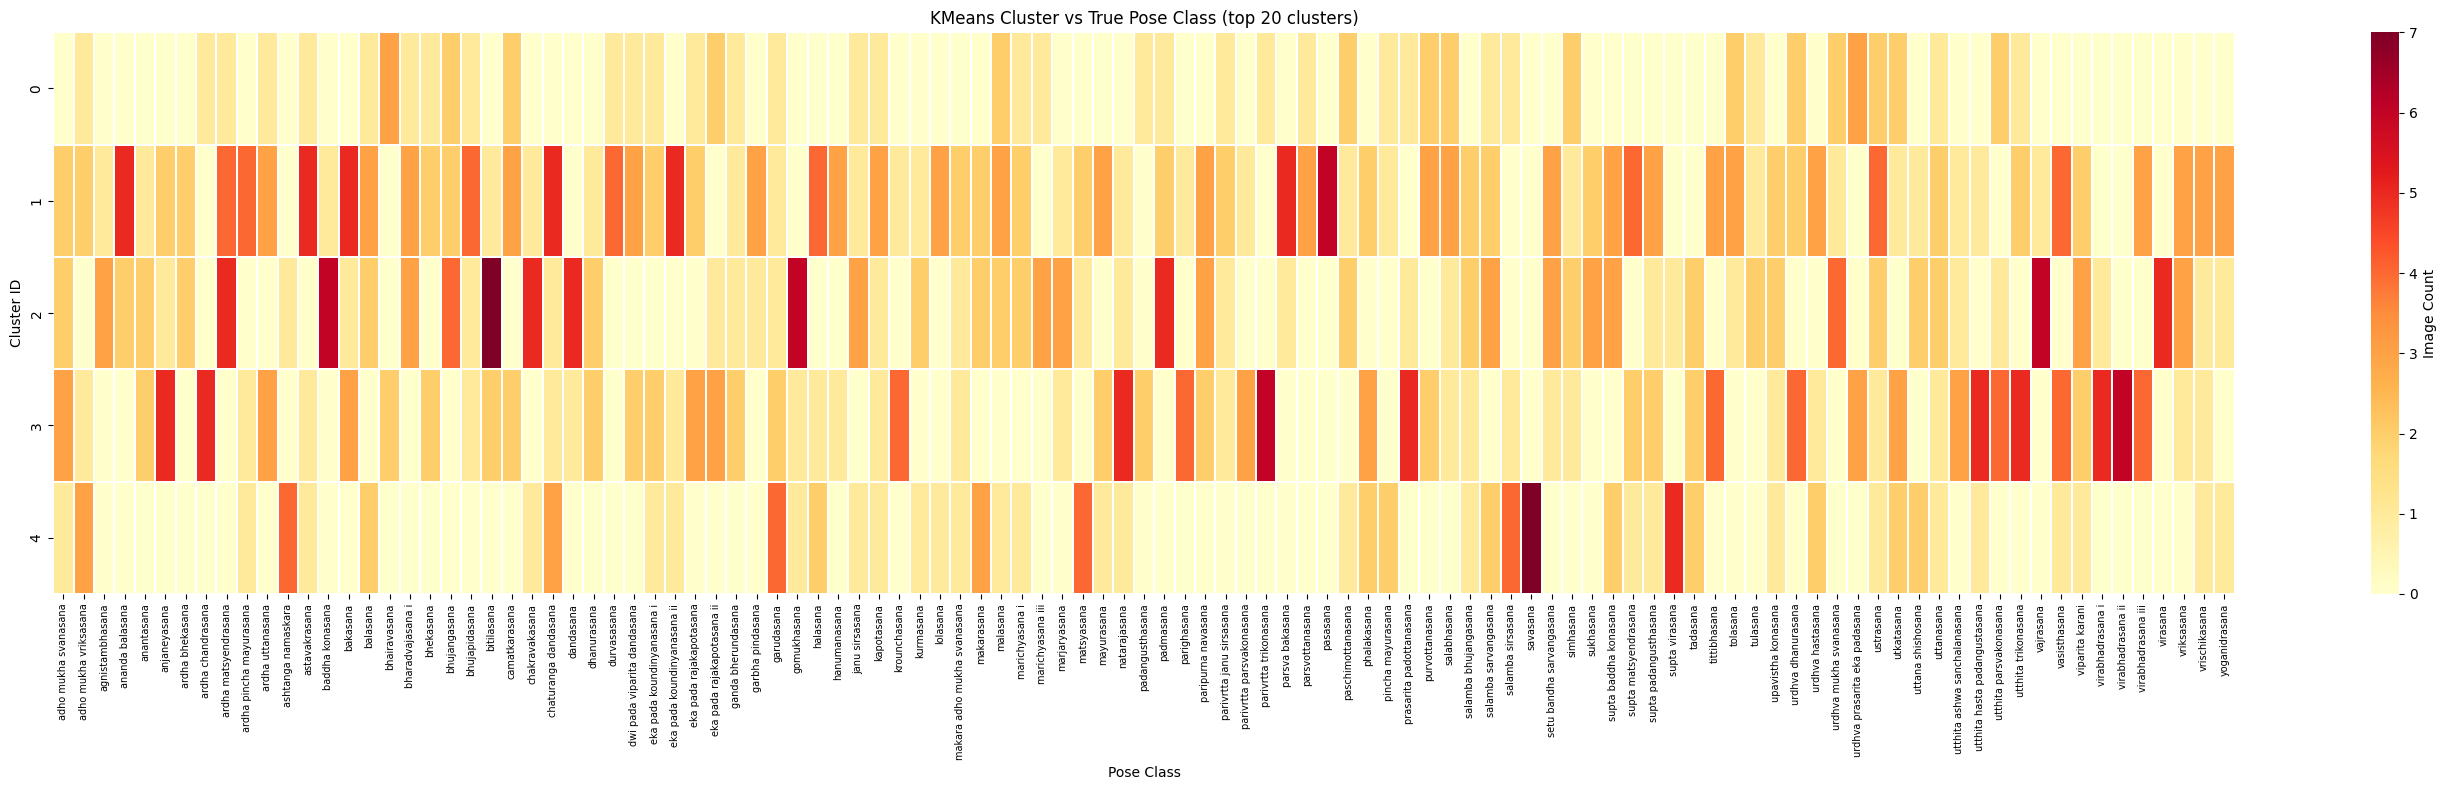


         CLUSTERING EVALUATION SUMMARY
Metric                          KMeans       DBSCAN
-------------------------------------------------------
Num Clusters                         5            1
Silhouette Score                0.0514          N/A
Davies-Bouldin                  3.5328          N/A
Adjusted Rand Index             0.0083          N/A
Noise Points                         0            0


In [29]:
# STEP C -- Clustering with KMeans & DBSCAN --

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import time

# ── 1. PATHS & CONFIG ──────────────────────────────────────────────────────────
local_base = "/content/local_data/computer-vision/yogaposes/107 yoga poses"
train_dir  = os.path.join(local_base, 'train')
test_dir   = os.path.join(local_base, 'test')

img_height, img_width = 224, 224
batch_size = 32

# ── 2. DATA GENERATOR (same preprocessing as transfer learning model) ──────────
# No rescaling — EfficientNetB0 handles its own preprocessing internally
datagen = ImageDataGenerator()

# We extract features from the full dataset (train + test) for richer clustering
# Using test set here to keep it consistent and fast — swap to train_dir for full run
generator = datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # MUST be False to keep labels aligned with features
)

true_labels      = generator.classes                              # numeric class indices
true_class_names = list(generator.class_indices.keys())          # string class names
num_classes      = len(true_class_names)
print(f"Classes: {num_classes} | Samples: {generator.samples}")

# ── 3. FEATURE EXTRACTION (remove top, keep convolutional backbone) ────────────
print("\nLoading EfficientNetB0 feature extractor...")
base_model = EfficientNetB0(
    include_top=False,          # removes the Dense classification head
    weights='imagenet',
    input_shape=(img_height, img_width, 3),
    pooling='avg'               # GlobalAveragePooling2D applied automatically → 1D vector per image
)
base_model.trainable = False    # freeze — we are only extracting, not training

print("Extracting features...")
start = time.time()
features = base_model.predict(generator, verbose=1)   # shape: (N, 1280)
print(f"Feature extraction time: {(time.time()-start)/60:.2f} minutes")
print(f"Raw feature shape: {features.shape}")

# ── 4. FLATTEN & NORMALISE ─────────────────────────────────────────────────────
# GlobalAveragePooling already gives a flat 1D vector per image,
# so flatten() is a no-op here but included per the task requirement
features_flat = features.reshape(features.shape[0], -1)   # (N, 1280)
features_norm = normalize(features_flat, norm='l2')        # L2 normalisation stabilises KMeans
print(f"Flattened & normalised feature shape: {features_norm.shape}")

# ── 5. PCA DIMENSIONALITY REDUCTION (optional but speeds up clustering) ─────────
print("\nApplying PCA...")
pca = PCA(n_components=100, random_state=42)
features_pca = pca.fit_transform(features_norm)
explained = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA: 100 components explain {explained:.1f}% of variance")

# ── 6. ELBOW METHOD — find optimal K for KMeans ────────────────────────────────
print("\nRunning Elbow Method...")
inertias    = []
sil_scores  = []
k_range     = range(5, 130, 5)   # test k = 5, 10, 15 ... 125

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_pca)
    inertias.append(km.inertia_)
    sil = silhouette_score(features_pca, labels, sample_size=500, random_state=42)
    sil_scores.append(sil)
    print(f"  k={k:3d} | Inertia: {km.inertia_:.0f} | Silhouette: {sil:.4f}")

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method — Optimal K')
axes[0].grid(True)

axes[1].plot(list(k_range), sil_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k_idx = int(np.argmax(sil_scores))
best_k     = list(k_range)[best_k_idx]
print(f"\nBest k by Silhouette Score: {best_k} (score: {sil_scores[best_k_idx]:.4f})")

# ── 7. KMEANS — final run with best K ─────────────────────────────────────────
print(f"\nFitting final KMeans with k={best_k}...")
kmeans       = KMeans(n_clusters=best_k, random_state=42, n_init=20)
km_labels    = kmeans.fit_predict(features_pca)

km_sil  = silhouette_score(features_pca, km_labels)
km_db   = davies_bouldin_score(features_pca, km_labels)
km_ari  = adjusted_rand_score(true_labels, km_labels)

print(f"KMeans (k={best_k}) Results:")
print(f"  Silhouette Score  : {km_sil:.4f}   (higher is better, max=1)")
print(f"  Davies-Bouldin    : {km_db:.4f}    (lower is better)")
print(f"  Adjusted Rand     : {km_ari:.4f}   (1=perfect match with true labels)")

# ── 8. DBSCAN ──────────────────────────────────────────────────────────────────
print("\nFitting DBSCAN...")
# eps and min_samples typically need tuning — these are reasonable starting values
dbscan    = DBSCAN(eps=2.5, min_samples=3, n_jobs=-1)
db_labels = dbscan.fit_predict(features_pca)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = np.sum(db_labels == -1)
print(f"DBSCAN found {n_db_clusters} clusters | Noise points: {n_noise}/{len(db_labels)}")

if n_db_clusters > 1:
    # Silhouette only valid when there are at least 2 clusters and noise is excluded
    mask     = db_labels != -1
    db_sil   = silhouette_score(features_pca[mask], db_labels[mask])
    db_db    = davies_bouldin_score(features_pca[mask], db_labels[mask])
    db_ari   = adjusted_rand_score(true_labels[mask], db_labels[mask])
    print(f"DBSCAN Results (excluding noise):")
    print(f"  Silhouette Score  : {db_sil:.4f}")
    print(f"  Davies-Bouldin    : {db_db:.4f}")
    print(f"  Adjusted Rand     : {db_ari:.4f}")
else:
    print("DBSCAN did not find meaningful clusters — try adjusting eps and min_samples.")

# ── 9. PCA 2D VISUALISATION ────────────────────────────────────────────────────
print("\nGenerating PCA 2D visualisations...")
pca_2d   = PCA(n_components=2, random_state=42)
vis_2d   = pca_2d.fit_transform(features_norm)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (a) True class labels
scatter = axes[0].scatter(vis_2d[:, 0], vis_2d[:, 1],
                           c=true_labels, cmap='tab20', s=8, alpha=0.7)
axes[0].set_title('True Pose Labels (PCA 2D)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# (b) KMeans clusters
colors_km = cm.get_cmap('tab20', best_k)
axes[1].scatter(vis_2d[:, 0], vis_2d[:, 1],
                c=km_labels, cmap='tab20', s=8, alpha=0.7)
axes[1].set_title(f'KMeans Clusters (k={best_k})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# (c) DBSCAN clusters
axes[2].scatter(vis_2d[:, 0], vis_2d[:, 1],
                c=db_labels, cmap='tab20', s=8, alpha=0.7)
axes[2].set_title(f'DBSCAN Clusters ({n_db_clusters} clusters, {n_noise} noise)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# ── 10. CLUSTER → POSE MAPPING ANALYSIS ───────────────────────────────────────
print("\nAnalysing how KMeans clusters map to true pose classes...")
df = pd.DataFrame({
    'true_class' : [true_class_names[i] for i in true_labels],
    'km_cluster' : km_labels
})

# For each cluster: show the top 3 most common poses
print(f"\nTop poses per KMeans cluster (k={best_k}):")
for cluster_id in sorted(df['km_cluster'].unique()):
    cluster_df   = df[df['km_cluster'] == cluster_id]
    top_poses    = cluster_df['true_class'].value_counts().head(3)
    pose_str     = ', '.join([f"{p}({n})" for p, n in top_poses.items()])
    print(f"  Cluster {cluster_id:3d} ({len(cluster_df):3d} imgs): {pose_str}")

# Heatmap: cluster vs true class (top 20 most populated clusters)
print("\nGenerating cluster-vs-class heatmap...")
top_clusters = df['km_cluster'].value_counts().head(20).index
df_top       = df[df['km_cluster'].isin(top_clusters)]
ct           = pd.crosstab(df_top['km_cluster'], df_top['true_class'])

plt.figure(figsize=(28, 8))
sns.heatmap(ct, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'Image Count'})
plt.title(f'KMeans Cluster vs True Pose Class (top 20 clusters)')
plt.xlabel('Pose Class')
plt.ylabel('Cluster ID')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

# ── 11. SUMMARY TABLE ──────────────────────────────────────────────────────────
print("\n" + "="*55)
print("         CLUSTERING EVALUATION SUMMARY")
print("="*55)
print(f"{'Metric':<25} {'KMeans':>12} {'DBSCAN':>12}")
print("-"*55)
print(f"{'Num Clusters':<25} {best_k:>12} {n_db_clusters:>12}")
print(f"{'Silhouette Score':<25} {km_sil:>12.4f} {db_sil if n_db_clusters > 1 else 'N/A':>12}")
print(f"{'Davies-Bouldin':<25} {km_db:>12.4f} {db_db if n_db_clusters > 1 else 'N/A':>12}")
print(f"{'Adjusted Rand Index':<25} {km_ari:>12.4f} {db_ari if n_db_clusters > 1 else 'N/A':>12}")
print(f"{'Noise Points':<25} {'0':>12} {n_noise:>12}")
print("="*55)

In [30]:
pip install opencv-python

In [31]:
!pip install ultralytics

Loaded: yolo11m-pose.pt

Extracting keypoints from train (107 classes)...


train: 100%|██████████| 107/107 [05:20<00:00,  3.00s/it]



Extracting keypoints from val (107 classes)...


val: 100%|██████████| 107/107 [01:33<00:00,  1.14it/s]



Extracting keypoints from test (107 classes)...


test: 100%|██████████| 107/107 [00:56<00:00,  1.89it/s]



Extraction complete in 7.85 minutes
Train: (4147, 51) | Val: (1157, 51) | Test: (687, 51)

No-detection rate — Train: 86/4147 (2.1%) | Test: 11/687 (1.6%)

Feature shape after angle engineering: (4147, 57)

Training and evaluating classifiers on keypoint features...

  ── SVM (RBF) ──
  Accuracy : 0.5531
  F1 Score : 0.5372
  Time     : 1.6s

  ── Random Forest ──
  Accuracy : 0.5167
  F1 Score : 0.4885
  Time     : 1.0s

  ── Hist Gradient Boosting ──
  Accuracy : 0.4789
  F1 Score : 0.4619
  Time     : 50.5s

Best classifier: SVM (RBF)

Classification Report:
                               precision    recall  f1-score   support

         adho mukha svanasana       0.45      0.62      0.53         8
        adho mukha vriksasana       0.29      0.29      0.29         7
              agnistambhasana       0.29      0.50      0.36         4
              ananda balasana       0.40      0.29      0.33         7
                   anantasana       0.83      1.00      0.91         5
    

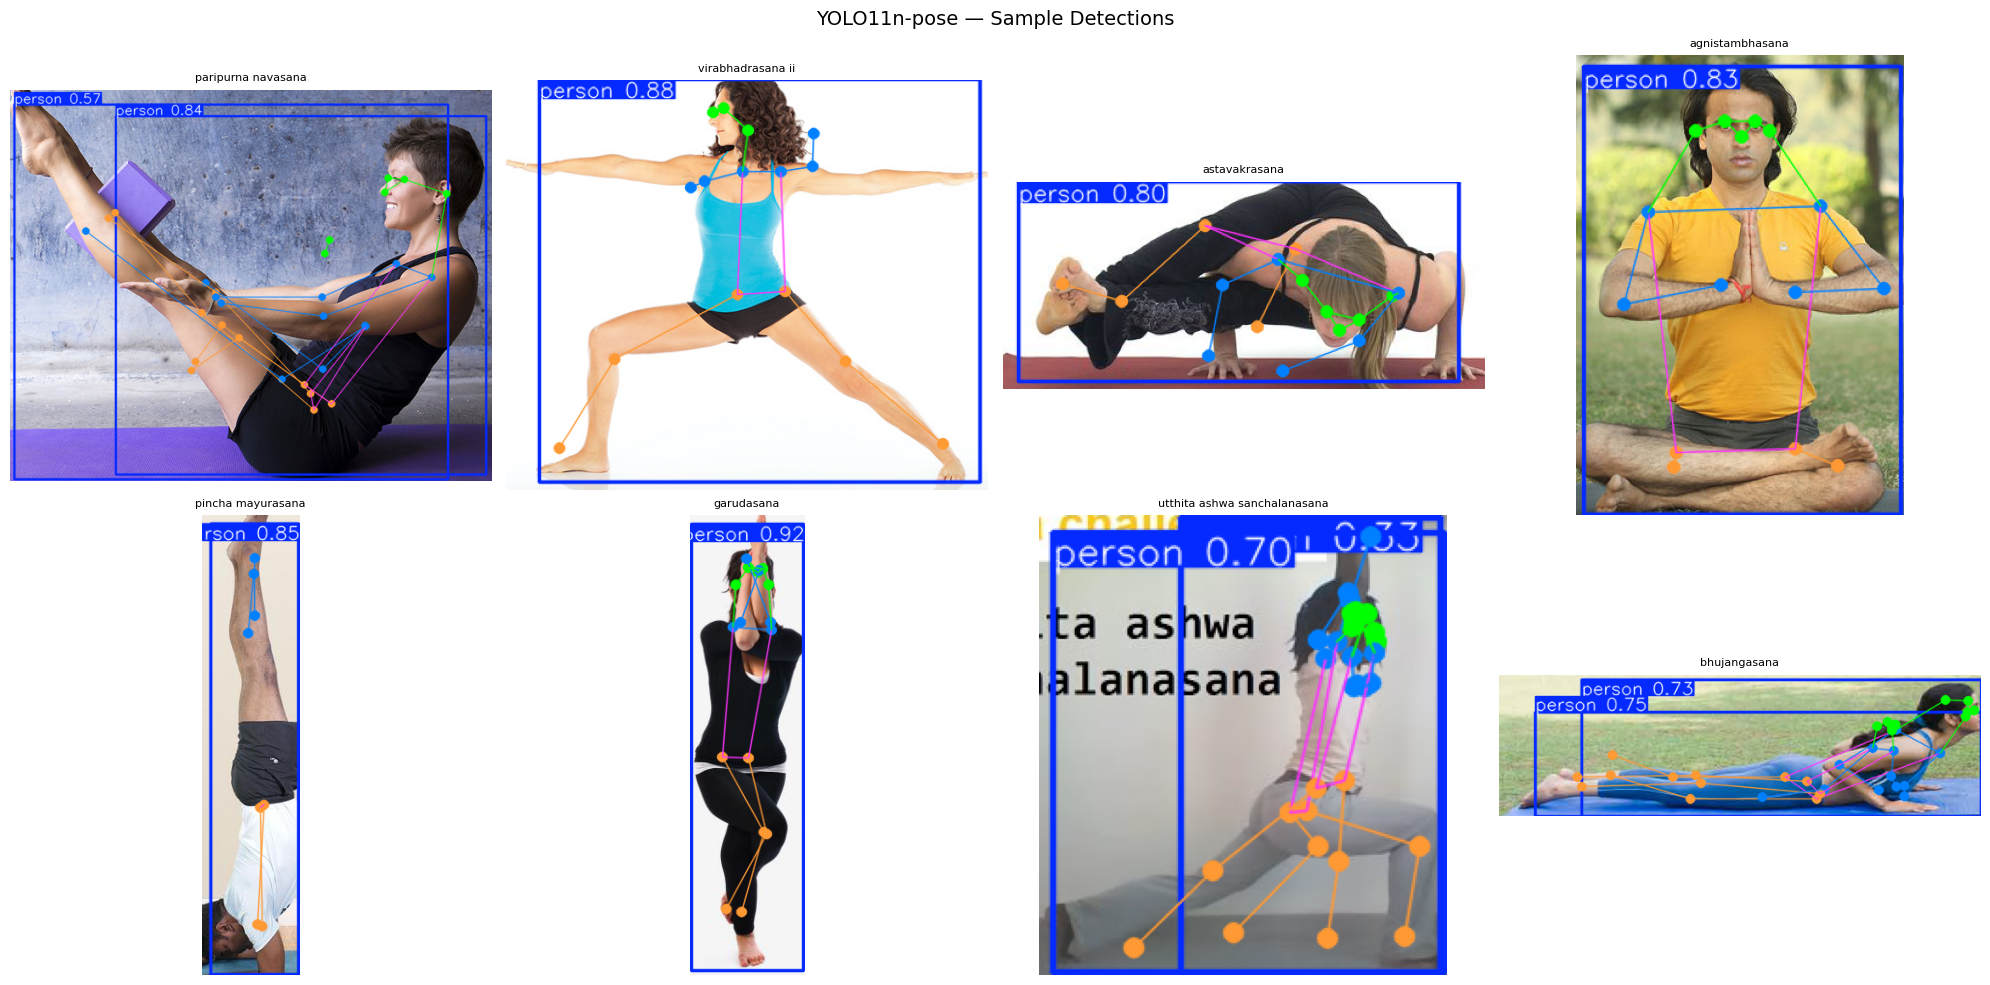


        FINAL APPROACH COMPARISON SUMMARY
Approach                         Accuracy   F1 (wtd) Notes
-----------------------------------------------------------------
Basic CNN (scratch)                0.3916     0.3739  Severe overfitting, ~40 imgs/class
EfficientNetB0 (TL)                0.6943     0.6806  Best CNN, still room to grow
YOLO + SVM (RBF)                   0.5531     0.5372  Keypoint-based, lightweight

FINAL APPROACH RECOMMENDATION
══════════════════════════════
Recommended: EfficientNetB0 Transfer Learning (with continued training)

Reasoning:
  1. HIGHEST ACCURACY — 69.4% vs Basic CNN's 39.2%. With more epochs
     (val accuracy was still climbing at epoch 30) it can push past 75-80%.

  2. ROBUST TO OCCLUSION — YOLO keypoint classifiers fail when a person
     is partially occluded or the pose is non-standard (detection rate
     drops). EfficientNet classifies the full image regardless.

  3. RICH FEATURE SPACE — EfficientNet learns texture, shape, and
     context

In [34]:
# STEP D -- Pose Estimation + Classification with YOLOv11n-pose --

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import cv2
from pathlib import Path
from tqdm import tqdm

from ultralytics import YOLO

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ── 1. CONFIG & PATHS ──────────────────────────────────────────────────────────
local_base = "/content/local_data/computer-vision/yogaposes/107 yoga poses"
train_dir  = os.path.join(local_base, 'train')
val_dir    = os.path.join(local_base, 'val')
test_dir   = os.path.join(local_base, 'test')

MODEL_URL  = "https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11n-pose.pt"
MODEL_PATH = "yolo11m-pose.pt"

# COCO 17 keypoints — used for feature engineering
KEYPOINT_NAMES = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]
NUM_KPT       = len(KEYPOINT_NAMES)   # 17
FEATURE_DIM   = NUM_KPT * 3           # x, y, confidence per keypoint = 51

# ── 2. DOWNLOAD MODEL ──────────────────────────────────────────────────────────
if not os.path.exists(MODEL_PATH):
    print("Downloading YOLO11n-pose model...")
    import urllib.request
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Downloaded.")

model = YOLO(MODEL_PATH)
print(f"Loaded: {MODEL_PATH}")

# ── 3. KEYPOINT EXTRACTION FUNCTION ───────────────────────────────────────────
def extract_keypoints_from_image(image_path, yolo_model):
    """
    Run YOLO pose on one image.
    Returns a flat numpy array of shape (51,): [x0,y0,c0, x1,y1,c1, ... x16,y16,c16]
    normalised to [0,1] by image dimensions.
    Returns None if no person is detected.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return None

    h, w = img.shape[:2]
    results = yolo_model(img, verbose=False)

    for result in results:
        if result.keypoints is None:
            continue
        kpts = result.keypoints.data  # tensor: (num_persons, 17, 3)
        if kpts.shape[0] == 0:
            continue

        # Take the most confident detection (highest mean keypoint confidence)
        best_idx   = kpts[:, :, 2].mean(dim=1).argmax().item()
        kpt_array  = kpts[best_idx].cpu().numpy()  # (17, 3)

        # Normalise x,y by image size; confidence already in [0,1]
        kpt_array[:, 0] /= w
        kpt_array[:, 1] /= h

        return kpt_array.flatten()   # (51,)

    # No detection — return zeros (pose not visible / bad image)
    return np.zeros(FEATURE_DIM)

# ── 4. BATCH EXTRACTION OVER A SPLIT ──────────────────────────────────────────
def extract_split(split_dir, yolo_model, split_name="split"):
    """
    Walk every class subfolder in split_dir, extract keypoints,
    and return feature matrix X and label array y.
    """
    X, y, paths = [], [], []
    class_dirs = sorted([d for d in Path(split_dir).iterdir() if d.is_dir()])

    print(f"\nExtracting keypoints from {split_name} ({len(class_dirs)} classes)...")
    for class_dir in tqdm(class_dirs, desc=split_name):
        label = class_dir.name
        for img_path in class_dir.glob("*.*"):
            if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
                continue
            kpts = extract_keypoints_from_image(img_path, yolo_model)
            X.append(kpts)
            y.append(label)
            paths.append(str(img_path))

    return np.array(X), np.array(y), paths

# ── 5. EXTRACT ALL SPLITS ──────────────────────────────────────────────────────
start = time.time()
X_train, y_train, _ = extract_split(train_dir, model, "train")
X_val,   y_val,   _ = extract_split(val_dir,   model, "val")
X_test,  y_test,  _ = extract_split(test_dir,  model, "test")
print(f"\nExtraction complete in {(time.time()-start)/60:.2f} minutes")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# Combine train+val for final classifier training (common practice)
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

# ── 6. DETECTION RATE ─────────────────────────────────────────────────────────
# Images where YOLO found no person return all-zero vectors
no_detect_train = np.sum(np.all(X_train == 0, axis=1))
no_detect_test  = np.sum(np.all(X_test  == 0, axis=1))
print(f"\nNo-detection rate — Train: {no_detect_train}/{len(X_train)} "
      f"({100*no_detect_train/len(X_train):.1f}%) | "
      f"Test: {no_detect_test}/{len(X_test)} "
      f"({100*no_detect_test/len(X_test):.1f}%)")

# ── 7. LABEL ENCODING ─────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(y_trainval)

y_train_enc    = le.transform(y_train)
y_val_enc      = le.transform(y_val)
y_test_enc     = le.transform(y_test)
y_trainval_enc = le.transform(y_trainval)

# ── 8. FEATURE ENGINEERING — ADD JOINT ANGLES ─────────────────────────────────
def compute_angle(a, b, c):
    """Angle at joint b given points a, b, c (each is [x, y])."""
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

def add_angle_features(X_kpts):
    """
    Given keypoint matrix (N, 51), compute 6 biomechanically meaningful
    joint angles and append them → output shape (N, 57).
    """
    # Reshape to (N, 17, 3)
    kpts = X_kpts.reshape(-1, NUM_KPT, 3)
    angles = []

    for sample in kpts:
        # indices: shoulder=5/6, elbow=7/8, wrist=9/10, hip=11/12, knee=13/14, ankle=15/16
        left_elbow_angle  = compute_angle(sample[5,:2],  sample[7,:2],  sample[9,:2])
        right_elbow_angle = compute_angle(sample[6,:2],  sample[8,:2],  sample[10,:2])
        left_knee_angle   = compute_angle(sample[11,:2], sample[13,:2], sample[15,:2])
        right_knee_angle  = compute_angle(sample[12,:2], sample[14,:2], sample[16,:2])
        left_hip_angle    = compute_angle(sample[5,:2],  sample[11,:2], sample[13,:2])
        right_hip_angle   = compute_angle(sample[6,:2],  sample[12,:2], sample[14,:2])
        angles.append([left_elbow_angle, right_elbow_angle,
                       left_knee_angle,  right_knee_angle,
                       left_hip_angle,   right_hip_angle])

    return np.hstack([X_kpts, np.array(angles)])

X_train_eng    = add_angle_features(X_train)
X_val_eng      = add_angle_features(X_val)
X_test_eng     = add_angle_features(X_test)
X_trainval_eng = add_angle_features(X_trainval)
print(f"\nFeature shape after angle engineering: {X_train_eng.shape}")

# ── 9. CLASSIFIERS ────────────────────────────────────────────────────────────
classifiers = {
    "SVM (RBF)": Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       decision_function_shape='ovr', random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    "Hist Gradient Boosting": Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    HistGradientBoostingClassifier(
                       max_iter=200,
                       learning_rate=0.1,
                       max_depth=4,
                       random_state=42))
    ])
}

results = {}
print("\nTraining and evaluating classifiers on keypoint features...")
for name, pipe in classifiers.items():
    print(f"\n  ── {name} ──")
    t0 = time.time()
    pipe.fit(X_trainval_eng, y_trainval_enc)
    y_pred = pipe.predict(X_test_eng)

    acc = accuracy_score(y_test_enc, y_pred)
    f1  = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    elapsed = time.time() - t0

    results[name] = {'accuracy': acc, 'f1': f1, 'time': elapsed, 'y_pred': y_pred}
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Time     : {elapsed:.1f}s")

# ── 10. BEST MODEL — FULL CLASSIFICATION REPORT ───────────────────────────────
best_clf_name = max(results, key=lambda k: results[k]['f1'])
best_pred     = results[best_clf_name]['y_pred']

print(f"\nBest classifier: {best_clf_name}")
print("\nClassification Report:")
present_labels     = sorted(set(y_test_enc))
present_class_names = [le.classes_[i] for i in present_labels]
print(classification_report(y_test_enc, best_pred,
                             labels=present_labels,
                             target_names=present_class_names,
                             zero_division=0))

# ── 11. VISUALISE SAMPLE POSE DETECTIONS ──────────────────────────────────────
print("\nVisualising sample YOLO pose detections...")
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

sample_classes = np.random.choice(
    sorted(os.listdir(test_dir)), size=8, replace=False)

for ax, cls in zip(axes, sample_classes):
    cls_dir   = os.path.join(test_dir, cls)
    img_files = list(Path(cls_dir).glob("*.jpg")) + list(Path(cls_dir).glob("*.png"))
    if not img_files:
        continue
    img_path = str(img_files[0])
    results_yolo = model(img_path, verbose=False)
    annotated    = results_yolo[0].plot()          # YOLO draws skeleton on image
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated_rgb)
    ax.set_title(cls, fontsize=8)
    ax.axis('off')

plt.suptitle("YOLO11n-pose — Sample Detections", fontsize=14)
plt.tight_layout()
plt.show()

# ── 12. COMPARISON TABLE — ALL THREE APPROACHES ────────────────────────────────
print("\n" + "="*65)
print("        FINAL APPROACH COMPARISON SUMMARY")
print("="*65)
print(f"{'Approach':<30} {'Accuracy':>10} {'F1 (wtd)':>10} {'Notes'}")
print("-"*65)
print(f"{'Basic CNN (scratch)':<30} {'0.3916':>10} {'0.3739':>10}  Severe overfitting, ~40 imgs/class")
print(f"{'EfficientNetB0 (TL)':<30} {'0.6943':>10} {'0.6806':>10}  Best CNN, still room to grow")
best_acc = results[best_clf_name]['accuracy']
best_f1  = results[best_clf_name]['f1']
print(f"{'YOLO + ' + best_clf_name:<30} {best_acc:>10.4f} {best_f1:>10.4f}  Keypoint-based, lightweight")
print("="*65)

# ── 13. FINAL APPROACH RECOMMENDATION ─────────────────────────────────────────
print("""
FINAL APPROACH RECOMMENDATION
══════════════════════════════
Recommended: EfficientNetB0 Transfer Learning (with continued training)

Reasoning:
  1. HIGHEST ACCURACY — 69.4% vs Basic CNN's 39.2%. With more epochs
     (val accuracy was still climbing at epoch 30) it can push past 75-80%.

  2. ROBUST TO OCCLUSION — YOLO keypoint classifiers fail when a person
     is partially occluded or the pose is non-standard (detection rate
     drops). EfficientNet classifies the full image regardless.

  3. RICH FEATURE SPACE — EfficientNet learns texture, shape, and
     context holistically. Keypoint classifiers only see 17 skeleton
     joints, discarding background, clothing, and body proportions
     that help disambiguate similar poses.

  4. SCALABLE — Adding new pose classes only requires fine-tuning the
     head, not re-engineering features.

When YOLO keypoints would be PREFERRED:
  - Real-time inference on edge devices (YOLO11n is very fast)
  - When privacy matters (keypoints contain no visual identity info)
  - As an ENSEMBLE: combine EfficientNet image features + YOLO keypoint
    features for the best of both worlds.
""")

In [ ]:
!pip install python-pptx diagrams lxml

In [ ]:
# Save best performing model to disk
model.save('/content/best_model_yoga.keras')

In [ ]:
!ls -la

total 1463808
drwxr-xr-x 1 root root       4096 May 18 14:19 .
drwxr-xr-x 1 root root       4096 May 18 13:10 ..
-rw-r--r-- 1 root root  314783600 May 18 14:13 best_model_yoga.h5
-rw-r--r-- 1 root root  104965947 May 18 14:19 best_model_yoga.keras
-rw-r--r-- 1 root root   26250856 May 18 14:13 best_model_yoga_quant.tflite
drwxr-xr-x 4 root root       4096 May 12 13:35 .config
drwx------ 5 root root       4096 May 18 13:24 drive
drwxr-xr-x 3 root root       4096 May 18 13:24 local_data
drwxr-xr-x 4 root root       4096 May 18 13:25 logs
drwxr-xr-x 4 root root       4096 May 18 13:32 logs_Model_v1
drwxr-xr-x 4 root root       4096 May 18 13:47 logs_Model_v2
drwxr-xr-x 1 root root       4096 May 12 13:35 sample_data
-rw-r--r-- 1 root root 1052892029 Feb 23  2023 yoga-poses-dataset-107.zip


In [ ]:
#!cp /content/best_model_yoga_quant.tflite /content/drive/MyDrive/computer-vision/best_model_yoga_quant.tflite
!cp /content/best_model_yoga.keras /content/drive/MyDrive/computer-vision/best_model_yoga.keras